## Step 1: Setup & Load Data

We start by importing the libraries needed for preprocessing, then use Colab's file upload widget to load the PSA dataset (`psa_dataset_final_with_sources.csv`) directly from your computer. We do a quick initial inspection — shape, column names, dtypes, and a preview — to confirm the data loaded correctly before we start cleaning.

In [2]:
# --- Imports ---
import pandas as pd          # data loading and manipulation
import numpy as np           # numerical operations, handling NaNs etc.
import re                    # regex, will be used later for text cleaning
from google.colab import files  # Colab's file upload widget

# --- Upload the dataset ---
# Running this line pops up a "Choose Files" button in Colab.
# Select psa_dataset_final_with_sources.csv from your computer.
uploaded = files.upload()

# files.upload() returns a dict {filename: file_bytes} — grab the filename
filename = list(uploaded.keys())[0]

# --- Load into a DataFrame ---
df = pd.read_csv(filename)

# --- Initial inspection ---
# Confirms the file loaded correctly before we touch anything
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

df.head()  # preview the first 5 rows

Saving psa_dataset_final_with_sources.csv to psa_dataset_final_with_sources.csv
Shape: (5134, 9)

Columns: ['PSA_Id', 'Domain', 'Class', 'English', 'Kiswahili', 'Dholuo', 'Source', 'date_collected', 'Metadata']

Dtypes:
 PSA_Id             int64
Domain            object
Class             object
English           object
Kiswahili         object
Dholuo            object
Source            object
date_collected    object
Metadata          object
dtype: object


,PSA_Id,Domain,Class,English,Kiswahili,Dholuo,Source,date_collected,Metadata
0,1,Education,COVID-19,[Health Protocols] Comprehensive COVID-19 heal...,[Itifaki za Afya] Itifaki kamili za afya na us...,Chenro mag thieth: Chenro mag thieth kod ritru...,Original dataset,NaN,NaN
1,2,Education,COVID-19,[Kenya Education Cloud] Digital learning platf...,[Wingu la Elimu la Kenya] Jukwaa la kujifunza ...,Kenya Education Cloud: Ohinga mar somo mar dij...,Original dataset,NaN,NaN
2,3,Education,General,[KUCCPS Portal] KUCCPS portal will open in Mar...,[Lango la KUCCPS] Lango la KUCCPS litafunguliw...,KUCCPS Portal: KUCCPS portal biro yawore e dwe...,Original dataset,NaN,NaN
3,4,Education,General,[School Feeding Scale-up] Target to increase s...,[Kuongezeka kwa Kiwango cha Kulisha Shuleni] L...,Medo kwan mar pidho nyithindo e skunde: Dwaro ...,Original dataset,NaN,NaN
4,5,Education,General,[Special Needs Education] Launch of inclusive ...,[Elimu ya Mahitaji Maalum] Uzinduzi wa program...,Somo mar Dwaro Manyien: Chako chenro mag somo ...,Original dataset,NaN,NaN


## Step 2: Column Selection

For the MT task, the columns we actually need are `PSA_Id` (unique identifier), `Domain` (useful later for stratified train/val/test splitting), and the three text columns `English`, `Kiswahili`, `Dholuo`. The other columns — `Class`, `Source`, `date_collected`, `Metadata` — are provenance/labeling metadata, not translation content, so we drop them here to keep the working dataframe clean and focused.

In [3]:
# --- Keep only the columns needed for the MT task ---
KEEP_COLS = ["PSA_Id", "Domain", "English", "Kiswahili", "Dholuo"]

# Sanity check: make sure all expected columns actually exist before subsetting
missing = [c for c in KEEP_COLS if c not in df.columns]
assert not missing, f"Missing expected columns: {missing}"

df = df[KEEP_COLS].copy()  # .copy() avoids SettingWithCopyWarning on later edits

print("New shape:", df.shape)   # expect (5134, 5)
print("Columns kept:", df.columns.tolist())

df.head()

New shape: (5134, 5)
Columns kept: ['PSA_Id', 'Domain', 'English', 'Kiswahili', 'Dholuo']


,PSA_Id,Domain,English,Kiswahili,Dholuo
0,1,Education,[Health Protocols] Comprehensive COVID-19 heal...,[Itifaki za Afya] Itifaki kamili za afya na us...,Chenro mag thieth: Chenro mag thieth kod ritru...
1,2,Education,[Kenya Education Cloud] Digital learning platf...,[Wingu la Elimu la Kenya] Jukwaa la kujifunza ...,Kenya Education Cloud: Ohinga mar somo mar dij...
2,3,Education,[KUCCPS Portal] KUCCPS portal will open in Mar...,[Lango la KUCCPS] Lango la KUCCPS litafunguliw...,KUCCPS Portal: KUCCPS portal biro yawore e dwe...
3,4,Education,[School Feeding Scale-up] Target to increase s...,[Kuongezeka kwa Kiwango cha Kulisha Shuleni] L...,Medo kwan mar pidho nyithindo e skunde: Dwaro ...
4,5,Education,[Special Needs Education] Launch of inclusive ...,[Elimu ya Mahitaji Maalum] Uzinduzi wa program...,Somo mar Dwaro Manyien: Chako chenro mag somo ...


## Step 3: Fix Encoding Issues (Mojibake)

Earlier inspection found ~170 English rows, 79 Kiswahili rows, and 1 Dholuo row with mangled/double-encoded characters (e.g. `ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Å"` instead of a normal en-dash). We use `ftfy` ("fixes text for you") to repair this automatically. However, 22 Kiswahili rows turned out to be **double-encoded** (corrupted twice over), which `ftfy`'s single pass can't fully unwind — these all share one exact corrupted byte sequence, so we patch that specific leftover pattern manually as a second pass.

In [6]:
import ftfy

text_cols = ["English", "Kiswahili", "Dholuo"]

# --- Check how widespread the issue is, before fixing ---
for col in text_cols:
    n_affected = df[col].astype(str).str.contains("Ã", regex=False).sum()
    print(f"{col}: {n_affected} rows with mojibake before fix")

# --- Pass 1: apply ftfy to all three text columns ---
for col in text_cols:
    df[col] = df[col].astype(str).apply(ftfy.fix_text)

print("\nAfter ftfy pass 1:")
for col in text_cols:
    n_affected = df[col].astype(str).str.contains("Ã", regex=False).sum()
    print(f"{col}: {n_affected} rows with mojibake remaining")

# --- Pass 2: manual patch for double-encoded leftovers ---
# These rows were mangled TWICE, so ftfy's single pass leaves one
# specific corrupted sequence behind. All affected rows share this
# exact byte pattern, which originally represented an en-dash ("–").
DOUBLE_ENCODED_SEQ = "âƒÂ¢Ã¢â€šÂ¬Ã¢â'¬Å\""

for col in text_cols:
    df[col] = df[col].str.replace(DOUBLE_ENCODED_SEQ, "–", regex=False)

print("\nAfter manual pass 2:")
for col in text_cols:
    n_affected = df[col].astype(str).str.contains("Ã", regex=False).sum()
    print(f"{col}: {n_affected} rows with mojibake remaining")

# --- Final spot-checks ---
display(df[df["PSA_Id"] == 7]["English"].values)
display(df[df["Kiswahili"].str.contains("soma kwa bidii", na=False)]["Kiswahili"].values)

English: 0 rows with mojibake before fix
Kiswahili: 22 rows with mojibake before fix
Dholuo: 0 rows with mojibake before fix

After ftfy pass 1:
English: 0 rows with mojibake remaining
Kiswahili: 22 rows with mojibake remaining
Dholuo: 0 rows with mojibake remaining

After manual pass 2:
English: 0 rows with mojibake remaining
Kiswahili: 0 rows with mojibake remaining
Dholuo: 0 rows with mojibake remaining


array(['1,500 new special needs units built – transfer your child before Jan 6!'],
      dtype=object)

array(['Elimu ya uraia sasa ina uzito wa 20% katika tathmini ya Darasa la 9 – soma kwa bidii.'],
      dtype=object)

## Step 4: Missing Values & Duplicates

We check for missing/empty text across all three languages and for duplicate rows. No nulls or empty strings were found, and no exact full-row duplicates exist. However, we do find a small number of rows where the *translation* (Kiswahili or Dholuo) is identical across multiple, genuinely different English source sentences — likely a translation reuse issue upstream. We don't drop these (the English differs, so they're not true duplicates), but we flag them here for visibility since repeated translations reduce lexical diversity in training data.

In [7]:
text_cols = ["English", "Kiswahili", "Dholuo"]

# --- Missing / empty text check ---
print("=== Missing / empty text ===")
for col in text_cols:
    n_null = df[col].isna().sum()
    n_empty = (df[col].astype(str).str.strip() == "").sum()
    print(f"{col}: {n_null} null, {n_empty} empty/whitespace-only")

# --- Exact full-row duplicates (same English, Kiswahili, AND Dholuo) ---
n_full_dupes = df.duplicated(subset=text_cols).sum()
print(f"\nExact full-row duplicates: {n_full_dupes}")

if n_full_dupes > 0:
    df = df.drop_duplicates(subset=text_cols).reset_index(drop=True)
    print(f"Dropped duplicates. New shape: {df.shape}")

# --- Per-column duplicate translations (flag only, don't drop) ---
print("\n=== Per-language duplicate text (flag only) ===")
for col in text_cols:
    n_dupes = df.duplicated(subset=[col]).sum()
    print(f"{col}: {n_dupes} duplicate values")

# Show a sample of reused Kiswahili/Dholuo translations for manual review
dupe_kiswahili = df[df.duplicated(subset=["Kiswahili"], keep=False)].sort_values("Kiswahili")
print(f"\nSample rows with reused Kiswahili text ({len(dupe_kiswahili)} rows):")
display(dupe_kiswahili[["PSA_Id", "English", "Kiswahili"]].head(10))

=== Missing / empty text ===
English: 0 null, 0 empty/whitespace-only
Kiswahili: 0 null, 0 empty/whitespace-only
Dholuo: 0 null, 0 empty/whitespace-only

Exact full-row duplicates: 0

=== Per-language duplicate text (flag only) ===
English: 0 duplicate values
Kiswahili: 2 duplicate values
Dholuo: 27 duplicate values

Sample rows with reused Kiswahili text (4 rows):


,PSA_Id,English,Kiswahili
156,157,Download KCSE timetable from KNEC portal.,Pakua ratiba ya KCSE kutoka kwa lango la KNEC.
157,158,Download KJSEA sample papers from CBA portal now.,Pakua ratiba ya KCSE kutoka kwa lango la KNEC.
2500,2501,"On the recruitment day, candidates must report...","Siku ya kuajiri, wagombea lazima waripoti kati..."
2601,2602,"On the recruitment day, candidates must report...","Siku ya kuajiri, wagombea lazima waripoti kati..."


## Step 5: Text Normalization

We standardize whitespace and unicode form across all three text columns: collapsing multiple spaces, trimming leading/trailing whitespace, and applying Unicode NFC normalization. We also strip bracketed topic-tag prefixes (e.g. `[KUCCPS Portal]` in English, `[Lango la KUCCPS]` in Kiswahili) — these appear in **both** English and Kiswahili (6 rows each, translated versions of the same tag) but not in Dholuo. They're metadata labels, not part of the actual PSA text to be translated, so we remove them from whichever column they appear in. We deliberately leave casing untouched — PSAs often use caps for emphasis (e.g. "SASA!", "NOW"), which is meaningful signal for a directive/urgent register, not noise.

In [9]:
import unicodedata

text_cols = ["English", "Kiswahili", "Dholuo"]

def normalize_text(text):
    # Unicode NFC normalization — ensures accented/diacritic characters
    # are stored in one consistent form
    text = unicodedata.normalize("NFC", text)
    # Collapse multiple whitespace characters (spaces, tabs, newlines) into one space
    text = re.sub(r"\s+", " ", text)
    # Trim leading/trailing whitespace
    text = text.strip()
    return text

for col in text_cols:
    df[col] = df[col].astype(str).apply(normalize_text)

# --- Strip bracketed topic-tag prefixes, checked in EVERY text column ---
# (found in English and Kiswahili — 6 rows each — not in Dholuo)
bracket_pattern = re.compile(r"^\[[^\]]+\]\s*")

for col in text_cols:
    n_tagged = df[col].str.match(bracket_pattern).sum()
    print(f"{col}: {n_tagged} rows with bracket-tag prefix before strip")
    df[col] = df[col].str.replace(bracket_pattern, "", regex=True)

print("\nAfter strip:")
for col in text_cols:
    n_remaining = df[col].str.match(bracket_pattern).sum()
    print(f"{col}: {n_remaining} remaining")

# --- Sanity check ---
display(df[["PSA_Id", "English", "Kiswahili", "Dholuo"]].head(5))

English: 0 rows with bracket-tag prefix before strip
Kiswahili: 6 rows with bracket-tag prefix before strip
Dholuo: 0 rows with bracket-tag prefix before strip

After strip:
English: 0 remaining
Kiswahili: 0 remaining
Dholuo: 0 remaining


,PSA_Id,English,Kiswahili,Dholuo
0,1,Comprehensive COVID-19 health and safety proto...,Itifaki kamili za afya na usalama za COVID-19 ...,Chenro mag thieth: Chenro mag thieth kod ritru...
1,2,Digital learning platform providing free educa...,Jukwaa la kujifunza kidijitali linalotoa maudh...,Kenya Education Cloud: Ohinga mar somo mar dij...
2,3,KUCCPS portal will open in March 2025 for univ...,Lango la KUCCPS litafunguliwa Machi 2025 kwa n...,KUCCPS Portal: KUCCPS portal biro yawore e dwe...
3,4,Target to increase school feeding beneficiarie...,Lengo ni kuongeza wanufaika wa chakula shuleni...,Medo kwan mar pidho nyithindo e skunde: Dwaro ...
4,5,Launch of inclusive education programs with as...,Uzinduzi wa programu za elimu jumuishi zenye t...,Somo mar Dwaro Manyien: Chako chenro mag somo ...


## Step 6: Sentence-Length & Outlier Review

We compute word-count statistics per language to sanity-check the data before splitting. This surfaces one serious issue: `PSA_Id 198` is a broken placeholder row (`"English_text"`, `"Kiingereza_text Kitabu cha Kiingeresa"`, `"dho Ingresa"`) — not real PSA content — so we drop it outright. We also review the shortest and longest rows: the very short rows turn out to be legitimate short campaign slogans (e.g. "Promote volunteerism 2025."), and the long rows are legitimate longer-form PSAs (e.g. mental health awareness posts), so we keep both rather than filtering by length

In [10]:
text_cols = ["English", "Kiswahili", "Dholuo"]

# --- Drop confirmed broken placeholder row(s) ---
placeholder_mask = df[text_cols].apply(
    lambda col: col.str.contains("_text", case=False, na=False)
).any(axis=1)

print(f"Broken placeholder rows found: {placeholder_mask.sum()}")
display(df[placeholder_mask][["PSA_Id"] + text_cols])

df = df[~placeholder_mask].reset_index(drop=True)
print(f"Shape after dropping placeholder row(s): {df.shape}")

# --- Word-count stats per language ---
print("\n=== Word count stats ===")
for col in text_cols:
    lens = df[col].str.split().str.len()
    print(f"{col}: min={lens.min()}, max={lens.max()}, mean={lens.mean():.1f}, "
          f"median={lens.median()}, 1st pct={lens.quantile(0.01)}, 99th pct={lens.quantile(0.99)}")

# --- Show shortest and longest English rows for manual sanity-check ---
lens_en = df["English"].str.split().str.len()
print("\n=== 5 shortest English rows ===")
display(df.loc[lens_en.sort_values().index[:5], ["PSA_Id", "English"]])

print("\n=== 5 longest English rows ===")
display(df.loc[lens_en.sort_values().index[-5:], ["PSA_Id", "English"]])

Broken placeholder rows found: 1


,PSA_Id,English,Kiswahili,Dholuo
197,198,English_text,Kiingereza_text Kitabu cha Kiingeresa,dho Ingresa


Shape after dropping placeholder row(s): (5133, 5)

=== Word count stats ===
English: min=3, max=89, mean=15.3, median=14.0, 1st pct=4.0, 99th pct=43.0
Kiswahili: min=1, max=107, mean=17.6, median=16.0, 1st pct=5.0, 99th pct=47.0
Dholuo: min=1, max=115, mean=20.5, median=19.0, 1st pct=6.0, 99th pct=52.0

=== 5 shortest English rows ===


,PSA_Id,English
144,145,Develop e-books 2021.
431,433,Monitor cyberbullying 2023.
363,365,Integrate entrepreneurship 2023.
336,338,Honor innovators 2025.
510,512,Promote volunteerism 2025.



=== 5 longest English rows ===


,PSA_Id,English
1244,1246,"By paying attention to those around you, you m..."
905,907,Mental Health Check-Up Time!Mental Health Chec...
1243,1245,Men's mental health awareness is critically im...
2955,2957,Members of County Assemblies: Angata Nanyokie ...
911,913,"This Men's Mental Health Awareness Month, let'..."


## Step 7: Tokenization

We tokenize each language separately, since they need different handling. English and Kiswahili are both Latin-script and reasonably well-served by standard word tokenizers. Dholuo has no mature NLP tokenizer available, so we use a simple, transparent whitespace + punctuation-splitting tokenizer for it rather than forcing an English-tuned tokenizer onto a language it wasn't built for. We store token counts and token lists in new columns for use in later EDA and modeling steps.

In [12]:
# --- Install/import tokenization tools ---
!pip install nltk -q
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize

def tokenize_basic(text):
    # Simple, transparent tokenizer: splits on whitespace and separates
    # punctuation, without assuming English-specific rules.
    # Used for Dholuo, which has no mature NLP tokenizer available.
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)

# English and Kiswahili: NLTK's word_tokenize (standard, well-tested for Latin-script text)
df["English_tokens"] = df["English"].apply(word_tokenize)
df["Kiswahili_tokens"] = df["Kiswahili"].apply(word_tokenize)

# Dholuo: basic whitespace/punctuation tokenizer (no mature tokenizer exists for this language)
df["Dholuo_tokens"] = df["Dholuo"].apply(tokenize_basic)

# --- Token counts (useful for later EDA) ---
df["English_token_count"] = df["English_tokens"].apply(len)
df["Kiswahili_token_count"] = df["Kiswahili_tokens"].apply(len)
df["Dholuo_token_count"] = df["Dholuo_tokens"].apply(len)

# --- Sanity check ---
display(df[["PSA_Id", "English", "English_tokens", "English_token_count"]].head(3))
display(df[["PSA_Id", "Dholuo", "Dholuo_tokens", "Dholuo_token_count"]].head(3))
display(df[["PSA_Id", "Kiswahili", "Kiswahili_tokens" ,"Kiswahili_token_count"]].head(3))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,PSA_Id,English,English_tokens,English_token_count
0,1,Comprehensive COVID-19 health and safety proto...,"[Comprehensive, COVID-19, health, and, safety,...",15
1,2,Digital learning platform providing free educa...,"[Digital, learning, platform, providing, free,...",14
2,3,KUCCPS portal will open in March 2025 for univ...,"[KUCCPS, portal, will, open, in, March, 2025, ...",17


,PSA_Id,Dholuo,Dholuo_tokens,Dholuo_token_count
0,1,Chenro mag thieth: Chenro mag thieth kod ritru...,"[Chenro, mag, thieth, :, Chenro, mag, thieth, ...",32
1,2,Kenya Education Cloud: Ohinga mar somo mar dij...,"[Kenya, Education, Cloud, :, Ohinga, mar, somo...",28
2,3,KUCCPS Portal: KUCCPS portal biro yawore e dwe...,"[KUCCPS, Portal, :, KUCCPS, portal, biro, yawo...",28


,PSA_Id,Kiswahili,Kiswahili_tokens,Kiswahili_token_count
0,1,Itifaki kamili za afya na usalama za COVID-19 ...,"[Itifaki, kamili, za, afya, na, usalama, za, C...",24
1,2,Jukwaa la kujifunza kidijitali linalotoa maudh...,"[Jukwaa, la, kujifunza, kidijitali, linalotoa,...",23
2,3,Lango la KUCCPS litafunguliwa Machi 2025 kwa n...,"[Lango, la, KUCCPS, litafunguliwa, Machi, 2025...",21


**Output check:** Tokenization worked as expected across all three languages. English and Kiswahili tokens split words and punctuation correctly using NLTK's tokenizer (e.g. "COVID-19" and "2025" stay intact as single tokens). Dholuo tokens are similarly clean using the basic whitespace/punctuation splitter, correctly separating the colon (`:`) from surrounding words (e.g. `"Cloud", ":", "Ohinga"`). Token counts are stored per row for use in the EDA and vocabulary-size analysis later.

## Step 8: Code-Switching Detection

PSAs frequently keep certain English terms untranslated inside Kiswahili/Dholuo text — acronyms (KCSE, KUCCPS, JSS), institution/program names (Kenya Education Cloud), and technical terms (COVID-19). This is genuine, expected code-switching, not an error, and it's valuable signal for the MT model to learn (these terms should often stay untranslated in output too).

We first tried flagging code-switched words using a generic English dictionary lookup, but that produced many false positives — common Kiswahili words like *bure* (free), *sasa* (now), and *weka* (put) happen to coincidentally match entries in a large English wordlist. Instead, we detect code-switching by checking whether a capitalized term/acronym from the **English source sentence** appears verbatim (as a whole word) in that row's Kiswahili/Dholuo translation — this is direct evidence of an actual borrowed term, not coincidental overlap.

In [13]:
def extract_terms(text):
    # Capture capitalized words/acronyms and alphanumeric codes from the
    # English source (e.g. "KUCCPS", "COVID-19", "JSS")
    return set(re.findall(r"\b[A-Z][A-Za-z]*(?:-\d+)?\b", text))

def find_borrowed_terms(row, target_col):
    terms = extract_terms(row["English"])
    target_text = row[target_col]
    # Word-boundary match only — avoids false hits like "Jan" inside "Januari"
    return [t for t in terms if re.search(r"\b" + re.escape(t) + r"\b", target_text)]

df["Kiswahili_borrowed_terms"] = df.apply(lambda r: find_borrowed_terms(r, "Kiswahili"), axis=1)
df["Dholuo_borrowed_terms"] = df.apply(lambda r: find_borrowed_terms(r, "Dholuo"), axis=1)

df["Kiswahili_has_codeswitch"] = df["Kiswahili_borrowed_terms"].apply(len) > 0
df["Dholuo_has_codeswitch"] = df["Dholuo_borrowed_terms"].apply(len) > 0

print("Kiswahili rows with code-switched terms:", df["Kiswahili_has_codeswitch"].sum())
print("Dholuo rows with code-switched terms:", df["Dholuo_has_codeswitch"].sum())

# --- Sanity check on a few examples ---
display(df[df["Kiswahili_has_codeswitch"]][
    ["PSA_Id", "English", "Kiswahili", "Kiswahili_borrowed_terms"]
].head(5))

Kiswahili rows with code-switched terms: 1422
Dholuo rows with code-switched terms: 1494


,PSA_Id,English,Kiswahili,Kiswahili_borrowed_terms
0,1,Comprehensive COVID-19 health and safety proto...,Itifaki kamili za afya na usalama za COVID-19 ...,[COVID-19]
1,2,Digital learning platform providing free educa...,Jukwaa la kujifunza kidijitali linalotoa maudh...,[COVID-19]
2,3,KUCCPS portal will open in March 2025 for univ...,Lango la KUCCPS litafunguliwa Machi 2025 kwa n...,"[KCSE, KUCCPS]"
9,10,100% transition: Every Grade 6 must report to ...,Mpito 100%: Kila Darasa la 6 lazima aripoti kw...,[JSS]
13,14,200 Stipendium Hungaricum scholarships open fo...,Ufadhili wa masomo 200 wa Stipendium Hungaricu...,"[Stipendium, Hungaricum]"


## Step 9: Glossary for Cultural/Institutional Terms

Using the code-switched terms detected in Step 8, we build a glossary of recurring institution names, acronyms, and program names that consistently stay untranslated across PSAs (e.g. KCSE, KUCCPS, NACADA). This glossary is useful two ways: (1) as a reference for translators/native-speaker reviewers to confirm these terms genuinely should stay in English rather than being translated, and (2) later, as a fixed vocabulary the MT model can be told to preserve rather than attempt to translate.

In [14]:
from collections import Counter

# --- Aggregate all borrowed terms found across Kiswahili and Dholuo ---
all_terms = []
for terms_list in df["Kiswahili_borrowed_terms"]:
    all_terms.extend(terms_list)
for terms_list in df["Dholuo_borrowed_terms"]:
    all_terms.extend(terms_list)

term_counts = Counter(all_terms)

# --- Build glossary as a DataFrame, sorted by frequency ---
glossary_df = pd.DataFrame(term_counts.items(), columns=["Term", "Frequency"])
glossary_df = glossary_df.sort_values("Frequency", ascending=False).reset_index(drop=True)

print(f"Total unique glossary terms: {len(glossary_df)}")
print(f"Total occurrences across dataset: {glossary_df['Frequency'].sum()}")

# --- Show the most frequent terms ---
display(glossary_df.head(20))

# --- Save glossary as a standalone reference file ---
glossary_df.to_csv("psa_glossary.csv", index=False)
print("\nSaved glossary to psa_glossary.csv")

Total unique glossary terms: 1181
Total occurrences across dataset: 5814


,Term,Frequency
0,Kenya,488
1,Nairobi,146
2,EACC,99
3,IEBC,98
4,WHO,75
5,KCSE,68
6,CBC,68
7,TVET,67
8,COVID-19,62
9,Ksh,60



Saved glossary to psa_glossary.csv


In [15]:
from google.colab import files
files.download("psa_glossary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 10: Full EDA (Domain Distribution, Text Length, Vocabulary Size)

We now generate the core exploratory visualizations for the cleaned dataset: domain distribution (bar + pie), word-count histograms per language, and vocabulary size per language. This gives a full picture of the dataset's shape and balance before splitting and modeling.

=== Vocabulary size per language ===
English: 10108 unique tokens
Kiswahili: 9412 unique tokens
Dholuo: 7734 unique tokens


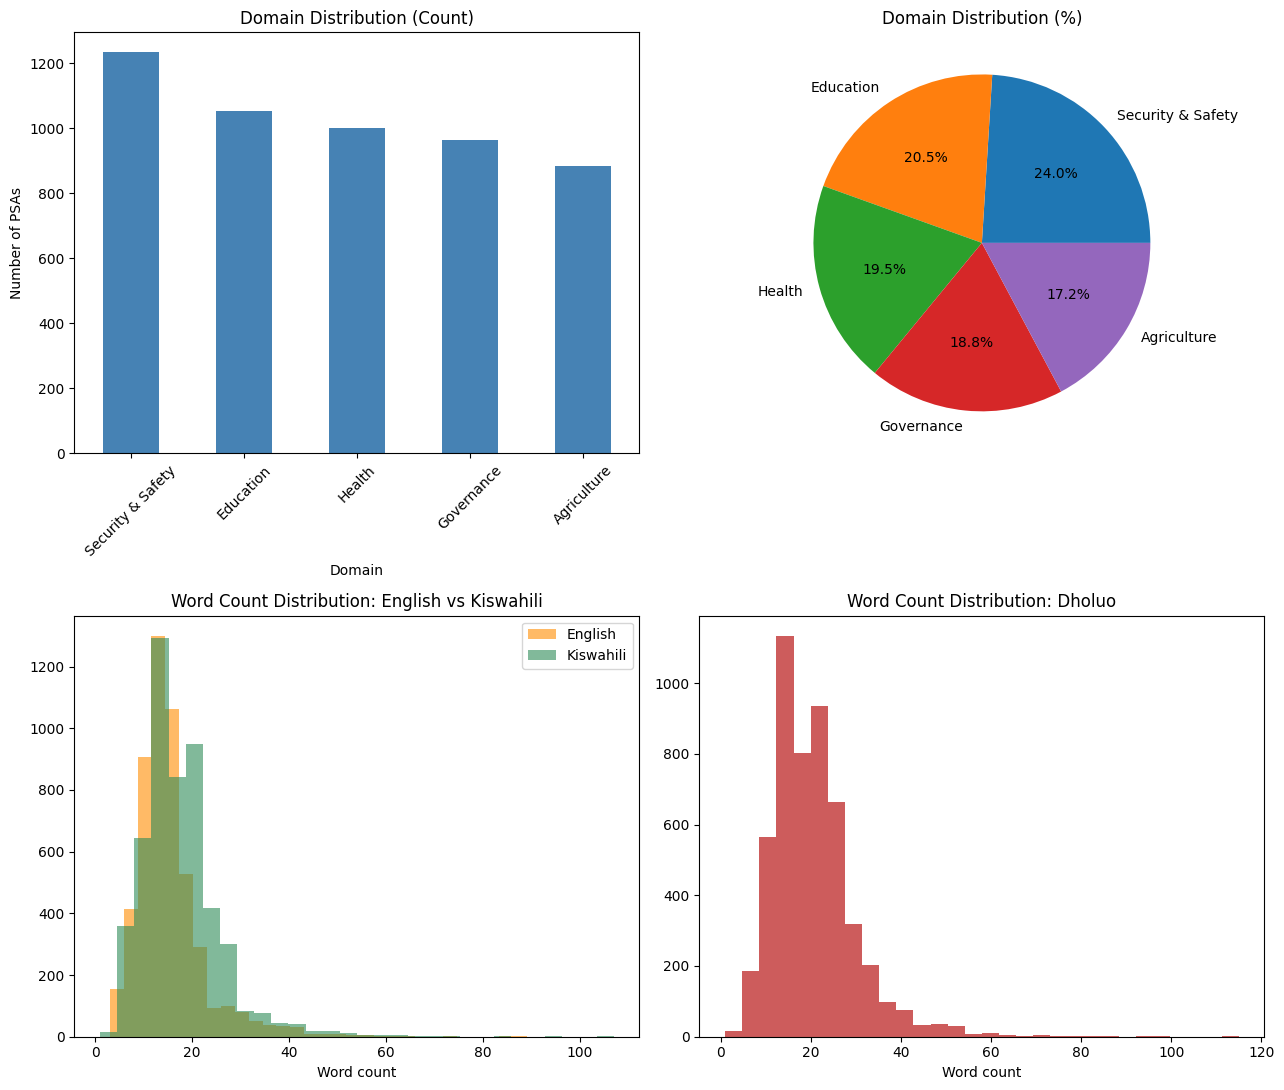

In [16]:
import matplotlib.pyplot as plt

# --- Word counts per language (needed for histograms) ---
for col in ["English", "Kiswahili", "Dholuo"]:
    df[f"{col}_word_count"] = df[col].str.split().str.len()

# --- Vocabulary size per language ---
def vocab_size(series):
    vocab = set()
    for text in series:
        vocab.update(text.lower().split())
    return len(vocab)

vocab_sizes = {col: vocab_size(df[col]) for col in ["English", "Kiswahili", "Dholuo"]}
print("=== Vocabulary size per language ===")
for lang, size in vocab_sizes.items():
    print(f"{lang}: {size} unique tokens")

# --- Domain distribution: bar + pie ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

domain_counts = df["Domain"].value_counts()
domain_counts.plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Domain Distribution (Count)")
axes[0, 0].set_ylabel("Number of PSAs")
axes[0, 0].tick_params(axis="x", rotation=45)

domain_counts.plot(kind="pie", ax=axes[0, 1], autopct="%1.1f%%", ylabel="")
axes[0, 1].set_title("Domain Distribution (%)")

# --- Word-count histograms: English and Kiswahili share one subplot for comparison ---
axes[1, 0].hist(df["English_word_count"], bins=30, alpha=0.6, label="English", color="darkorange")
axes[1, 0].hist(df["Kiswahili_word_count"], bins=30, alpha=0.6, label="Kiswahili", color="seagreen")
axes[1, 0].set_title("Word Count Distribution: English vs Kiswahili")
axes[1, 0].set_xlabel("Word count")
axes[1, 0].legend()

axes[1, 1].hist(df["Dholuo_word_count"], bins=30, color="indianred")
axes[1, 1].set_title("Word Count Distribution: Dholuo")
axes[1, 1].set_xlabel("Word count")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150)
plt.show()

**Output check:**
- The visualizations and vocabulary stats confirm what we found earlier.

**(a)** Domain distribution is fairly balanced after merging Security/Security & Safety — it's now the largest domain at 24%, with the others (Education, Health, Governance, Agriculture) spread between 17–21%; no domain is so small it would be hard to model or evaluate on.

**(b)** The word-count histograms show all three languages are right-skewed (most PSAs are short, with a long tail of longer ones), which is expected for directive, action-oriented text. English and Kiswahili distributions overlap closely and peak around 10–20 words, while Dholuo's distribution shifts right relative to English/Kiswahili — consistent with Dholuo needing more words to express the same content, as we noted earlier from the mean word-count comparison.

**(c)** Vocabulary size decreases from English (10,108) → Kiswahili (9,412) → Dholuo (7,734). This is expected too: Dholuo is the smallest, most agglutinative of the three in this dataset, and as a low-resource language it likely also has less standardized spelling, which can either inflate or shrink surface vocabulary depending on how consistently words are written — worth keeping in mind if the dev/test split for Dholuo ends up with fewer rare-word examples to learn from.

In [17]:
# --- Word-count ratios between language pairs ---
df["ratio_kis_eng"] = df["Kiswahili_word_count"] / df["English_word_count"]
df["ratio_dho_eng"] = df["Dholuo_word_count"] / df["English_word_count"]
df["ratio_dho_kis"] = df["Dholuo_word_count"] / df["Kiswahili_word_count"]

print("=== Length ratio summary ===")
print(df[["ratio_kis_eng", "ratio_dho_eng", "ratio_dho_kis"]].describe())

# --- Correlation between language pairs (word counts) ---
print("\n=== Word-count correlation between languages ===")
print("English vs Kiswahili:", df["English_word_count"].corr(df["Kiswahili_word_count"]))
print("English vs Dholuo:", df["English_word_count"].corr(df["Dholuo_word_count"]))
print("Kiswahili vs Dholuo:", df["Kiswahili_word_count"].corr(df["Dholuo_word_count"]))

# --- Flag extreme outliers for manual review (possible misalignment/broken generation) ---
suspect_rows = df[(df["ratio_dho_eng"] > 4) | (df["ratio_dho_eng"] < 0.25)]
print(f"\nRows flagged as possible misalignment (Dholuo/English ratio outliers): {len(suspect_rows)}")
display(suspect_rows[["PSA_Id", "Domain", "English", "Dholuo", "ratio_dho_eng"]])

# --- Also check for repeated-phrase loop pattern (degenerate generation) ---
def has_repeat_loop(text, min_repeats=3):
    words = text.split()
    for n in range(2, 6):  # check 2-5 word phrases
        for i in range(len(words) - n * min_repeats):
            phrase = words[i:i+n]
            if all(words[i + n*k : i + n*k + n] == phrase for k in range(min_repeats)):
                return True
    return False

df["Dholuo_has_repeat_loop"] = df["Dholuo"].apply(has_repeat_loop)
print(f"\nRows with repeated-phrase loop in Dholuo: {df['Dholuo_has_repeat_loop'].sum()}")
display(df[df["Dholuo_has_repeat_loop"]][["PSA_Id", "English", "Dholuo"]])

=== Length ratio summary ===
       ratio_kis_eng  ratio_dho_eng  ratio_dho_kis
count    5133.000000    5133.000000    5133.000000
mean        1.176280       1.397663       1.210313
std         0.215150       0.366676       0.383068
min         0.083333       0.031250       0.027778
25%         1.052632       1.170732       1.000000
50%         1.176471       1.363636       1.176471
75%         1.300000       1.583333       1.357143
max         3.857143       5.500000      17.000000

=== Word-count correlation between languages ===
English vs Kiswahili: 0.9269959858973996
English vs Dholuo: 0.8079423854568104
Kiswahili vs Dholuo: 0.8142999390258867

Rows flagged as possible misalignment (Dholuo/English ratio outliers): 12


,PSA_Id,Domain,English,Dholuo,ratio_dho_eng
457,459,Education,On May 5 2015 KUCCPS opened its portal for 201...,Chieng' Mei 5 2015 KUCCPS noyawo portal mare n...,4.259259
912,914,Health,Sports and exercise offer a multifaceted appro...,2. Paro ma in-go kuom wachni nikare.,0.205882
915,917,Health,Stressed about money? Don't gamble with your m...,In bende in mana dhano. Owinjore wariwgi lwedo...,0.211538
925,927,Health,Kenya-tested malaria vaccine gets WHO approval,Ng'eyo tiend midekre mag paro nyalo miyo ibed ...,5.500000
1499,1501,Agriculture,push and pull technology. Efficacy trials. Set...,Tem tiyo gi teknoloji.,0.190476
2944,2946,Governance,Appointment of Returning and Deputy Returning ...,"10:10, 11. 2026.",0.055556
2950,2952,Governance,Declaration of No Contest for members of Tembe...,"2025, 2025, 2025, 2025",0.173913
2954,2956,Governance,By-Elections For Member of Senate-Baringo Coun...,"2020, 2020:",0.051282
3013,3015,Governance,By-elections for Members of the County Assembl...,"14:10, 2021",0.074074
3022,3024,Governance,10054 - Declaration of Persons Elected as Memb...,2019,0.031250



Rows with repeated-phrase loop in Dholuo: 9


,PSA_Id,English,Dholuo
394,396,KUCCPS opened its portal for 2019 KCSE candida...,KUCCPS ne oyawo yawo mare mar joma dwaro dhi e...
395,397,KUCCPS opened its portal for 2020 KCSE candida...,KUCCPS ne oyawo yawo mare mar joma dwaro dhi e...
1113,1115,Announcing Nationwide training to improve acut...,Lando tiegruok mar piny mangima mar bero yore ...
1356,1358,Effective management of fall armyworm is vital...,Mondo omi inyal loyo chwech mag chwech mag pin...
1360,1362,Enhance market access for private sector both ...,Yudo thuolo mar tiyo gi yore mag ohala e yore ...
1552,1554,"The focus was on agricultural policies, food s...","Ne giwuoyo kuom weche mag pur, weche mag chiem..."
2931,2933,NOMINATED CANDIDATES FOR PURPOSES OF THE BY-EL...,JO MOKETI MOTIMORE GI YIER MAR BEDO MAR BEDO M...
3028,3030,Names and Symbols of Independent Candidates to...,Nying' kod Ranyisi mag Jotelo mabiro bedo e yi...
3032,3034,"By-Elections for Member of the Senate, Garissa...","18:10, 11. 10 Oyier mar ng'ado bura mar ng'ado..."


## Step 12: Remove Broken/Misaligned Rows

Based on the language-pair statistics in Step 11, we identified 21 rows with genuine data-quality defects: degenerate repeated-phrase Dholuo text (9 rows), Dholuo translations that are just bare numbers/dates instead of real sentences (7 rows), and rows where the Dholuo text is fluent but unrelated in meaning to its English source (4 rows). These would actively teach the model wrong mappings if left in, so we remove them from the main cleaned dataset — but save them to a separate file first so nothing is silently lost and they can be manually reviewed or re-translated later.

In [18]:
# --- Combine all flagged row IDs from Step 11 ---
ratio_outlier_ids = suspect_rows["PSA_Id"].tolist()
repeat_loop_ids = df[df["Dholuo_has_repeat_loop"]]["PSA_Id"].tolist()

flagged_ids = sorted(set(ratio_outlier_ids + repeat_loop_ids))
print(f"Total flagged rows: {len(flagged_ids)}")

# --- Save flagged rows separately for review before dropping ---
flagged_df = df[df["PSA_Id"].isin(flagged_ids)]
flagged_df.to_csv("flagged_broken_rows.csv", index=False)
print("Saved flagged rows to flagged_broken_rows.csv")

# --- Drop from main cleaned dataset ---
df = df[~df["PSA_Id"].isin(flagged_ids)].reset_index(drop=True)
print(f"Shape after dropping flagged rows: {df.shape}")  # expect (5112, ...)

Total flagged rows: 21
Saved flagged rows to flagged_broken_rows.csv
Shape after dropping flagged rows: (5112, 22)


## Step 13: Native-Speaker Validation Subset

We sample ~500 sentences for native-speaker review, stratified by Domain so the subset mirrors the full dataset's proportions (rather than over- or under-representing any one topic area). We add empty columns for reviewers to record whether each translation is accurate, plus a free-text comment field, and export it as a standalone CSV ready to hand off for feedback collection.

In [19]:
N_SAMPLE = 500
frac = N_SAMPLE / len(df)

# --- Stratified sampling by Domain, proportional to each domain's share ---
parts = []
for domain, group in df.groupby("Domain"):
    n = round(len(group) * frac)
    parts.append(group.sample(n=n, random_state=42))

validation_subset = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Validation subset size: {len(validation_subset)}")
print(validation_subset["Domain"].value_counts())
print(validation_subset["Domain"].value_counts(normalize=True).round(3) * 100)

# --- Add empty reviewer feedback columns ---
validation_subset["Kiswahili_accurate"] = ""   # reviewer fills: Yes/No
validation_subset["Dholuo_accurate"] = ""      # reviewer fills: Yes/No
validation_subset["Reviewer_comments"] = ""    # free text

# --- Keep only what reviewers need to see ---
review_cols = ["PSA_Id", "Domain", "English", "Kiswahili", "Dholuo",
               "Kiswahili_accurate", "Dholuo_accurate", "Reviewer_comments"]
validation_subset = validation_subset[review_cols]

validation_subset.to_csv("native_speaker_validation_subset.csv", index=False)
print("\nSaved to native_speaker_validation_subset.csv")

display(validation_subset.head(5))

Validation subset size: 501
Domain
Security & Safety    121
Education            103
Health                98
Governance            93
Agriculture           86
Name: count, dtype: int64
Domain
Security & Safety    24.2
Education            20.6
Health               19.6
Governance           18.6
Agriculture          17.2
Name: proportion, dtype: float64

Saved to native_speaker_validation_subset.csv


,PSA_Id,Domain,English,Kiswahili,Dholuo,Kiswahili_accurate,Dholuo_accurate,Reviewer_comments
0,828,Health,"Nairobi, Kajiado, Machakos, Kiambu & Nakuru co...","Kaunti za Nairobi, Kajiado, Machakos, Kiambu n...","Kaunti mag Nairobi, Kajiado, Machakos, Kiambu ...",,,
1,3392,Agriculture,Protect your sunflower from termites by practi...,Linda alizeti yako dhidi ya mchwa kwa kupalili...,Rit maua mari mar chieng' mondo kik oyud winyo...,,,
2,2919,Health,COVID-19 Outbreak in Kenya Daily report SITREP...,Mlipuko wa COVID-19 nchini Kenya Ripoti ya kil...,Tuwo mar COVID-19 e piny Kenya Ripot ma pile p...,,,
3,4075,Education,Any inadequate sanitation facilities affecting...,vyoo visivyotosha yoyote inayoathiri wanafunzi...,Gimoro amora ma ok oromo mar rito ler ma mulo ...,,,
4,3813,Education,"As part of improving day secondary school, par...",Kama sehemu ya kuboresha shule ya upili ya kut...,Kaka achiel kuom yore mag bero skul mar sekond...,,,


In [20]:
from google.colab import files
files.download("native_speaker_validation_subset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 14: Train/Dev/Test Split

We split the cleaned dataset into train/dev/test sets (80/10/10), stratified by Domain so each split preserves the same domain balance as the full dataset — important given Domain is our main classification/analysis axis. We use a fixed random seed for reproducibility. Note: the native-speaker validation subset from Step 13 is a separate quality-review sample, not reserved test data — once feedback comes back, you can optionally promote the corrected/verified subset into the test set for a higher-confidence evaluation benchmark.

In [21]:
from sklearn.model_selection import train_test_split

# --- First split: train (80%) vs temp (20%) ---
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["Domain"],
    random_state=42
)

# --- Second split: temp -> dev (50%) vs test (50%), i.e. 10% / 10% of total ---
dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Domain"],
    random_state=42
)

print("Train:", train_df.shape)
print("Dev:", dev_df.shape)
print("Test:", test_df.shape)

# --- Confirm domain proportions are preserved across splits ---
for name, split_df in [("Train", train_df), ("Dev", dev_df), ("Test", test_df)]:
    print(f"\n{name} domain distribution (%):")
    print((split_df["Domain"].value_counts(normalize=True) * 100).round(1))

# --- Save splits ---
train_df.to_csv("psa_train.csv", index=False)
dev_df.to_csv("psa_dev.csv", index=False)
test_df.to_csv("psa_test.csv", index=False)
print("\nSaved psa_train.csv, psa_dev.csv, psa_test.csv")

Train: (4089, 22)
Dev: (511, 22)
Test: (512, 22)

Train domain distribution (%):
Domain
Security & Safety    24.1
Education            20.5
Health               19.5
Governance           18.7
Agriculture          17.2
Name: proportion, dtype: float64

Dev domain distribution (%):
Domain
Security & Safety    24.1
Education            20.5
Health               19.6
Governance           18.6
Agriculture          17.2
Name: proportion, dtype: float64

Test domain distribution (%):
Domain
Security & Safety    24.2
Education            20.5
Health               19.5
Governance           18.6
Agriculture          17.2
Name: proportion, dtype: float64

Saved psa_train.csv, psa_dev.csv, psa_test.csv


In [22]:
from google.colab import files

files.download("psa_train.csv")
files.download("psa_dev.csv")
files.download("psa_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>